# Myocardial infarction risk models based on ECG - comparison

The project compares two algorithms for myocardial infarction detection based on ECG signals. 
The first algorithm was implemented manually based on the article and for the second one external implementation was run on the same data in order to compare the results.

## Dataset

The ECG data used in this project are derived from the PTB Diagnostic ECG Database v1.0.0, available through PhysioNet.
The database is licensed under the Open Data Commons Attribution License v1.0 (ODC-By 1.0).
The full dataset is not included in this repository.

This database contains records from 290 patients, including 52 records from healthy patients and 148 records in which myocardial infarction was diagnosed.

In [ ]:
file_list_MI = []
file_list_HC = []

data_list_MI = [] #myocardial infarction
data_list_HC = [] #healthy controls

## QRS detection and data preparation

Records of ECG signal were loaded and divided into two cathegories based on the diagnosis included in the database: cases with myocardial infarction and healthy controls. For each of the records R-peaks were detected using the Pan-Tompkins algorithm. The implementation was obtained from the Github 'Kushagra Sharma antimattercorrade, Pan Tompkins QRS Wave Detection Algorithm Python Implementation, https://github.com/antimattercorrade/Pan_Tompkins_QRS_Detection'. Based on the R-peaks heartbeats were segmented and used for the classification. 

In [ ]:
   
    # My original analysis starts here.
    
    cycles = [] # heartbeats for the current record
    
    result = result[1:-1] # The first and last heartbeat was excluded in case they were incomplete.
    result = result[result > 250] 
    mini = min((115200-401), (signal.size-401))
    result = result[result < mini]
    print('R-peaks positions:')
    print(result)
    for start, end in zip(result[0:-1] - 250, result[0:-1] + 401): # each beat has length of 651 samples
        cycle = signal[start:end]
        cycles.append(cycle) # list of numpy ndarrays - beats of one record
    if (heartRate > 25 and heartRate < 220 and set == 1):
        for i in cycles:
            data_list_MI.append(i)
    elif (heartRate > 25 and heartRate < 220 and set == 0):
        for i in cycles:
            data_list_HC.append(i)
    else:
        print('Record dismissed - wrong heartrate.')

    print("Number of current record's heartbeats:")
    print(len(cycles))
    
    if (set == 1):
        print('Number of heartbeats up to this point:')
        print(len(data_list_MI))
    else:
        print('Number of heartbeats up to this point:')
        print(len(data_list_HC))
    
    if (len(cycles) >= 1):
        plt.plot(cycles[0], color = 'blue')  
    
    print("Shape of the heartbeats array used for classification:")
    if (set == 1):
        data_array_MI=np.vstack(data_list_MI)
        print(data_array_MI.shape)
    else:
        data_array_HC=np.vstack(data_list_HC)
        print(data_array_HC.shape)


In [ ]:
# Number of all the heartbeats for healthy controls and myocardial infarction was displayed.
labels_HC=[0 for i in data_list_HC]
labels_MI=[1 for i in data_list_MI]
print(len(labels_HC),len(labels_MI)) 

In [ ]:
data_array = np.concatenate([data_array_HC, data_array_MI])
labels = labels_HC + labels_MI
print(len(data_array),len(labels))
print(data_array[0:5])
print(labels[0:5])

In [ ]:
label_array=np.hstack(labels)

## First algorithm

The heartbeat classification algorithm described in the article 'Application of deep convolutional neural networks for automatic detection of myocardial infarction from electrocardiographic signals' was chosen for independent implementation. The model was implemented, then the model's hyperparameters were tuned to improve its classification performance. 

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [ ]:
# K-fold Cross Validation model evaluation
fold_no = 1
acc_per_fold = [] #save accuracy from each fold
czulosc_per_fold = [] 
specyf_per_fold = [] 
precyzja_per_fold = [] 
F1_per_fold = [] 
tp_per_fold = []
tn_per_fold = []
fp_per_fold = []
fn_per_fold = []
together = 0
together_czulosc = 0
together_precyzja = 0
together_specyf = 0
together_F1 = 0
together_tp = 0
together_tn = 0
together_fp = 0
together_fn = 0

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, regularizers, optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
import keras
from tensorflow.keras.metrics import Precision, Recall 
from tensorflow.keras.backend import epsilon 


In [ ]:
for train_val, test in cv.split(data_array, label_array): # 
        
    print('   ')
    print(f'Training for fold {fold_no} ...')
    
    #Splitting the datasets for training and validation process
    
    from sklearn.model_selection import train_test_split
    train_X, val_X, train_y, val_y = train_test_split(data_array[train_val], label_array[train_val], test_size=0.3, random_state=42, stratify=label_array[train_val]) # daj tu stratify=label_array[train_val] - proporcja w outputach bedzie taka sama jak w label_array[train_val]

    train_reshaped = [0] * len(train_X)
    train_transformed = [0] * len(train_X)
    
    #Scale data
    
    for i in range (len(train_X)):
        scaler = StandardScaler()
        train_reshaped[i] = train_X[i].reshape(-1, 1) 
        scaler.fit(train_reshaped[i]) # Mean and standard variation for each heartbeat are calculated 
        train_transformed[i] = scaler.transform(train_reshaped[i])
    
    train_transformed = np.array(train_transformed)
        
    val_reshaped = [0] * len(val_X)
    val_transformed = [0] * len(val_X)
        
    for i in range (len(val_X)):
        scaler2 = StandardScaler()
        val_reshaped[i] = val_X[i].reshape(-1, 1)
        scaler2.fit(val_reshaped[i])
        val_transformed[i] = scaler2.transform(val_reshaped[i])
    val_transformed = np.array(val_transformed)
        
    test_X = data_array[test]
    test_reshaped = [0] * len(test_X)
    test_transformed = [0] * len(test_X)
    
    for i in range (len(test_X)):
        scaler3 = StandardScaler()
        test_reshaped[i] = test_X[i].reshape(-1, 1)
        scaler3.fit(test_reshaped[i])
        test_transformed[i] = scaler3.transform(test_reshaped[i])
    test_transformed = np.array(test_transformed)
        
    #Reshape train and test data 
    
    train_transformed = train_transformed.reshape(train_transformed.shape[0], train_transformed.shape[1], 1)
    val_transformed = val_transformed.reshape(val_transformed.shape[0], val_transformed.shape[1], 1)
    test_transformed = test_transformed.reshape(test_transformed.shape[0], test_transformed.shape[1], 1)
    
    print("train_transformed new shape: ", train_transformed.shape)
    print("val_transformed new shape: ", val_transformed.shape)
    print("test_transformed new shape: ", test_transformed.shape)
    
    print("train_transformed: ", train_transformed)
    
    
    model = Sequential()
    model.add(layers.Conv1D(3, 102, strides=1, activation='leaky_relu', input_shape=(651,1)))
    model.add(layers.MaxPooling1D(2, strides=2))
    model.add(layers.Conv1D(10, 24, strides=1, activation='leaky_relu')) 
    model.add(layers.Dropout(0.2))
    model.add(layers.MaxPooling1D(2, strides=2))
    model.add(layers.Conv1D(10, 11, strides=1, activation='leaky_relu'))
    model.add(layers.Dropout(0.2))
    model.add(layers.MaxPooling1D(2, strides=2))
    model.add(layers.Conv1D(10, 9, strides=1, activation='leaky_relu'))
    model.add(layers.MaxPooling1D(2, strides=2))
    model.add(layers.Flatten())
    model.add(layers.Dense(30, activation='leaky_relu'))
    model.add(layers.Dense(10, activation='leaky_relu'))
    model.add(layers.Dense(2, activation='softmax'))

    model.summary()
       
    mom = 0.0003
    lr = 0.0007
    
    from keras import metrics
    model.compile(optimizer=optimizers.Adam(learning_rate=lr)), loss = 'sparse_categorical_crossentropy', metrics=['accuracy']) #, tf.keras.metrics.Recall(class_id=1), tf.keras.metrics.Precision(class_id=1)]) # tf.keras.metrics.F1Score()]) #, f1_score]) # było (działało samo accuracy): metrics =[metrics.Accuracy(), metrics.TruePositives(), metrics.TrueNegatives(), metrics.FalsePositives(), metrics.FalseNegatives(), metrics.Precision(), metrics.Recall()]) #keras.metrics.F1Score()])#albo: keras.metrics.Precision(), itd. Było wcześniej: metrics=['accuracy'])
    model_history = model.fit(train_X, train_y, epochs=60, batch_size=10, verbose=1, validation_data = (val_X, val_y)) # bylo train_X i val_X

    print(model_history.history.keys())
    
    #Evaluate the model - report accuracy and capture it into a list for future reporting
    
    scores = model.evaluate(test_X, label_array[test], verbose=0) 
    print("scores:")
    print(scores)
    
    
    pred_test = model.predict(test_X, verbose=1)

    
    predicted = np.empty([len(pred_test)])
    for i in range (0, (len(pred_test))):
        if (pred_test[i][0] > pred_test[i][1]):
            predicted[i] = 0
        else:
            predicted[i] = 1
    
    print("len(predicted):") 
    print(len(predicted))
    print("len(test_transformed):") 
    print(len(test_transformed))
    
    print("predicted:")
    print(predicted)
    
    print("test_transformed:")
    print(test_transformed)
    
    #scores[0] - loss
    #scores[1] - accuracy
    #scores[2] - recall
    #scores[3] - precision
    #scores[4] - f1_score
                  
    #Metrics for each 10 fold were calculated
    
    acc_per_fold.append(scores[1] * 100) 
    print("acc_per_fold ")
    print([fold_no-1])
    print(": ")
    print(acc_per_fold[fold_no-1])
    
    sensitivity_per_fold.append(tp/(tp + fn)) #z 13.01.
    print("sensitivity_per_fold ")
    print([fold_no-1])
    print(": ")
    print(sensitivity_per_fold[fold_no-1])
    
    specificity_per_fold.append(tn/(tn+fp))
    print("specificity_per_fold ")
    print([fold_no-1])
    print(": ")
    print(specificity_per_fold[fold_no-1])
                  
    precision_per_fold.append(tp/(tp+fp))
    print("precision_per_fold ")
    print([fold_no-1])
    print(": ")
    print(precision_per_fold[fold_no-1])
    
    F1_per_fold.append(2*((tp/(tp+fp))*(tp/(tp + fn))/((tp/(tp+fp))+(tp/(tp + fn))))) 
    print("F1_per_fold ")
    print([fold_no-1])
    print(": ")
    print(F1_per_fold[fold_no-1])
    
    tp_per_fold.append(tp)
    print("tp_per_fold ")
    print([fold_no-1])
    print(": ")
    print(tp_per_fold[fold_no-1])
    
    tn_per_fold.append(tn)
    print("tn_per_fold ")
    print([fold_no-1])
    print(": ")
    print(tn_per_fold[fold_no-1])
    
    fp_per_fold.append(fp)
    print("fp_per_fold ")
    print([fold_no-1])
    print(": ")
    print(fp_per_fold[fold_no-1])
    
    fn_per_fold.append(fn)
    print("fn_per_fold ")
    print([fold_no-1])
    print(": ")
    print(fn_per_fold[fold_no-1]) 
    
    fold_no = fold_no + 1
    
    
# Final metrics were calculated as means from all folds used for cross-validation
    
for acc in acc_per_fold:                                         
    print("accuracy for this fold is: ", acc)
    together = together + acc
average = together/(fold_no-1)
print("Average accuracy is: ", average)

for sensitivity in sensitivity_per_fold:                                 
    print("sensitivity for this fold is: ", sensitivity)
    together_sensitivity = together_sensitivity + sensitivity
average_sensitivity = together_sensitivity/(fold_no-1)
print("Average sensitivity is: ", average_sensitivity)

for precision in precision_per_fold:
    print("precision for this fold is: ", precision)
    together_precision = together_precision + precision
average_precision = together_precision/(fold_no-1)
print("Average precision is: ", average_precision) 

for specificity in specificity_per_fold:
    print("specificity for this fold is: ", specificity)
    together_specificity = together_specificity + specificity
average_specificity = together_specificity/(fold_no-1)
print("Average specificity is: ", average_specificity) 

for F1 in F1_per_fold:
    print("F1 for this fold is): ", F1)
    together_F1 = together_F1 + F1
average_F1 = together_F1/(fold_no-1)
print("Average F1 is: ", average_F1) 

for TP in tp_per_fold:                                 
    print("tp for this fold is): ", TP)
    together_tp = together_tp + TP
average_tp = together_tp/(fold_no-1)
print("Average tp is: ", average_tp)

for TN in tn_per_fold:                                 
    print("tn for this fold is: ", TN)
    together_tn = together_tn + TN
average_tn = together_tn/(fold_no-1)
print("Average tn is: ", average_tn)

for FP in fp_per_fold:                                 
    print("fp for this fold is: ", FP)
    together_fp = together_fp + FP
average_fp = together_fp/(fold_no-1)
print("Average fp is: ", average_fp)

for FN in fn_per_fold:                                 
    print("fn for this fold is: ", FN)
    together_fn = together_fn + FN
average_fn = together_fn/(fold_no-1)
print("Average fn is: ", average_fn)


## Second algorithm

The implementation of the second algorithm chosen for the comparison was found on GitHub repository: 
Lynda Starkus, Abnormal_ECG_Myocardial_infraction_cnn https://github.com/Lynda-Starkus/Abnormal_ECG_Myocardial_infraction_cnn. The author implemented part of the algorithm described in the paper 'ECG beat classification: a deep transferable representation'. 

The main idea is to subsequently use part of the previously trained model to classify ECG recordings as either normal or with myocardial infarction. The GitHub implementation uses the developed neural network to classify ECG signals into normal and abnormal beat classes. 

The implementation was run on the same data that were used for the first algorithm.


## Results

The results for both models are presented below as well as the confusion matrix for the first model.

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Model 1", "Model 2"],
    "Accuracy": ["99,55%", "99,85%"],
    "Sensitivity": ["99,66%", "-"],
    "Precision" : ["99,80%", "-"],
    "Specificity" : ["98,95%", "-"],
    "F1-score": ["99,73%", "99,91%"]
})

results.style.set_table_attributes('style="width: 100%;"')

,Model,Accuracy,Sensitivity,Precision,Specificity,F1-score
0,Model 1,"99,55%","99,66%","99,80%","98,95%","99,73%"
1,Model 2,"99,85%",-,-,-,"99,91%"


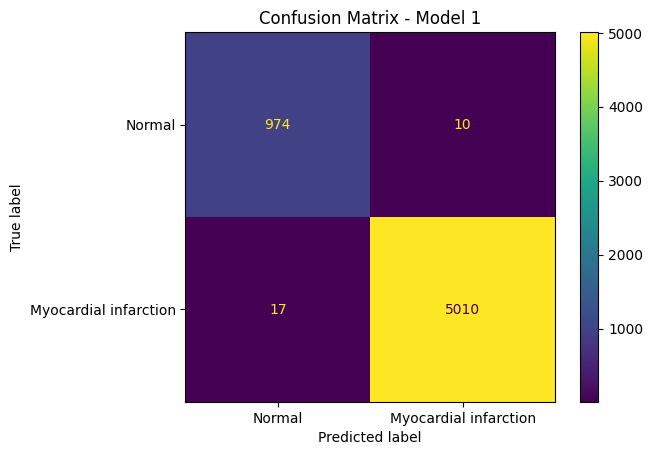

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

cm1 = np.array([
    [974, 10],
    [17,5010]
])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm1,
    display_labels=["Normal", "Myocardial infarction"]
)

disp.plot()
plt.title("Confusion Matrix - Model 1")

plt.show()

## Conclusion

Both algorithms achieved high accuracy in classifying normal and myocardial infarction beats. These and other algorithms based on neural networks may find application in systems supporting the work of physicians and contribute to more efficient healthcare.